# Fraud Detection on the PaySim Dataset

**A complete, end-to-end project: exploration, feature engineering, modelling and explainability.**

---

## Contents

| Step | Section | What happens |
|---|---|---|
| 1 | Setup and data | Load the data, check it is clean |
| 2 | Exploring the problem | Class imbalance, where fraud hides, when it happens |
| 3 | Feature engineering | Build every feature, with the reason for each |
| 4 | Multicollinearity | Check the features are not duplicating each other, and fix it |
| 5 | Feature sets | Three sets, so we can see exactly where performance comes from |
| 6 | Splitting the data | Random split **and** time-based split, compared |
| 7 | Class imbalance | How we tell the models fraud matters more |
| 8 | Training | Four models, with a full training log |
| 9 | Threshold tuning | Turning probabilities into good decisions |
| 10 | Hyperparameter tuning | Searching for better model settings |
| 11 | Final model | The finished result and its scores |
| 12 | Explainability | What the models actually learned |
| 13 | Conclusions | Findings and next steps |

---

## The one idea to keep in mind

Some columns in PaySim make fraud **too easy** to predict, because of how the simulator
created the data. Fraud almost always empties the victim's account *exactly*, so
`amount` equals `oldbalanceOrg`. A model given both columns can rediscover that shortcut and
score close to perfect — but that score would not survive on real bank data.

We handle this openly: we train on three feature sets, report the realistic one as our main
result, and use the others to demonstrate the effect rather than hide it.

## Step 1 — Setup and data

In [7]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     StratifiedKFold)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, classification_report,
                             confusion_matrix)
from statsmodels.stats.outliers_influence import variance_inflation_factor

import xgboost as xgb

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

print('Libraries loaded.')

Libraries loaded.


In [8]:
# Update this path to point at your copy of the dataset.
DATA_PATH = r'C:\Users\amare\OneDrive\Desktop\Projects\Finance Hackathon\stdbank-pip\data\01_raw\Synthetic_Financial_Datasets_For_Fraud_Detection_resample.csv'

df = pd.read_csv(DATA_PATH)

print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
print(f'\nMissing values: {df.isna
().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
df.head()

Rows    : 636,262
Columns : 11

Missing values: 0
Duplicate rows: 0


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,182,CASH_IN,100328.70,C197678862,3389602.37,3489931.07,C386191921,219735.14,119406.44,0,0
1,210,PAYMENT,11660.99,C2009511954,94054.00,82393.01,M564284134,0.00,0.00,0,0
2,403,CASH_IN,230751.30,C1132312861,23117012.10,23347763.39,C1025694734,951294.81,720543.51,0,0
3,328,PAYMENT,17833.60,C1191709365,0.00,0.00,M293024801,0.00,0.00,0,0
4,563,CASH_OUT,246476.67,C342438889,0.00,0.00,C2087488957,4226850.16,4473326.82,0,0


## Step 2 — Exploring the problem

Before building anything, we need to understand three things: how rare fraud is, where it
occurs, and when it occurs. Each answer feeds directly into a modelling decision later.

### 2.1 Fraud is very rare

This is the defining challenge. A model that simply predicts "never fraud" would be right
99.87% of the time and catch nothing. **This is why we never use accuracy as our metric.**

In [9]:
counts = df['isFraud'].value_counts()
print(f'Normal transactions : {counts[0]:,}')
print(f'Fraud transactions  : {counts[1]:,}')
print(f'Fraud rate          : {df.isFraud.mean():.4%}')
print(f'\nFor every 1 fraud there are {counts[0] / counts[1]:.0f} normal transactions.')

Normal transactions : 635,413
Fraud transactions  : 849
Fraud rate          : 0.1334%

For every 1 fraud there are 748 normal transactions.


### 2.2 Fraud only occurs in two transaction types

Fraud appears **only** in `TRANSFER` and `CASH_OUT`, never in `PAYMENT`, `CASH_IN` or
`DEBIT`. This matches how the fraud works: the criminal transfers money out of the victim's
account, then cashes it out. This tells us transaction type is an important feature.

          transactions  fraud_count  fraud_rate
type                                           
CASH_IN         139684            0    0.000000
CASH_OUT        223846          417    0.001863
DEBIT             4147            0    0.000000
PAYMENT         215315            0    0.000000
TRANSFER         53270          432    0.008110


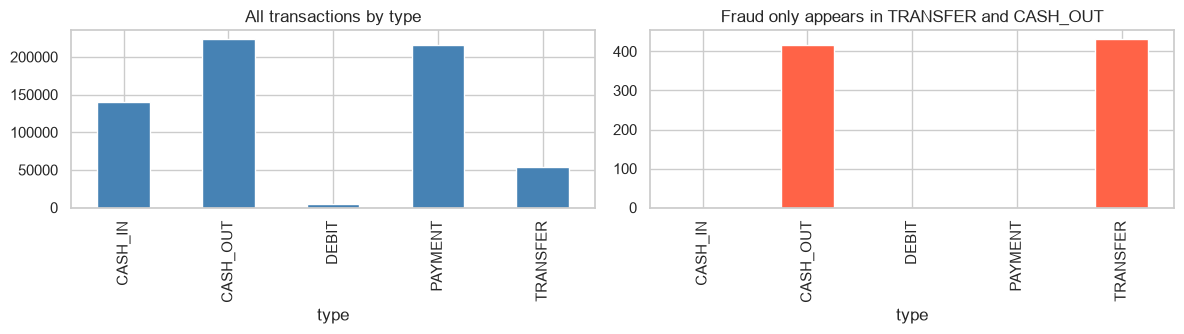

In [10]:
fraud_by_type = df.groupby('type')['isFraud'].agg(['size', 'sum', 'mean'])
fraud_by_type.columns = ['transactions', 'fraud_count', 'fraud_rate']
print(fraud_by_type.to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
fraud_by_type['transactions'].plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('All transactions by type')
fraud_by_type['fraud_count'].plot(kind='bar', ax=ax[1], color='tomato')
ax[1].set_title('Fraud only appears in TRANSFER and CASH_OUT')
plt.tight_layout()
plt.show()

### 2.3 Fraud is steady, genuine activity is not

The `step` column counts hours from 1 to 744, covering 30 days, so `step % 24` gives the
position within a repeating 24 step cycle.

**An important limit on what we can claim.** The data card tells us a step is an hour. It does
*not* tell us what clock time step 1 corresponds to. So we cannot say position 3 means 3am,
and we do not. We only use what the data supports: the cycle exists, some positions carry far
less traffic than others, and the fraud count stays roughly flat across all of them. That is
enough to make position a useful feature without inventing a start time.

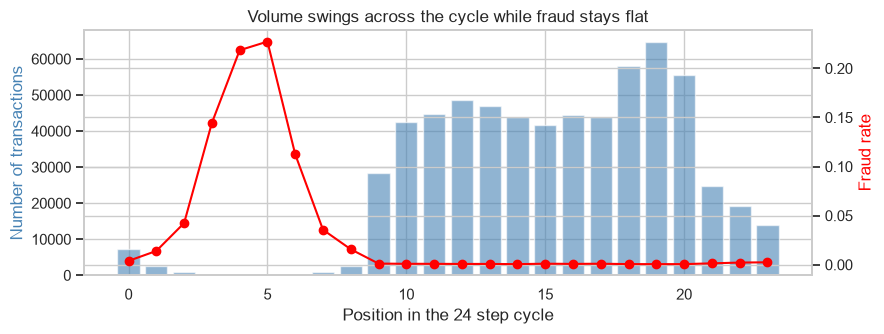

Fraud count per cycle position stays in a narrow band:
  minimum 25, maximum 43
Transaction volume does not:
  minimum 119, maximum 64,659


In [11]:
df['cycle_position'] = df['step'] % 24

cycle = df.groupby('cycle_position')['isFraud'].agg(['size', 'sum', 'mean'])
cycle.columns = ['transactions', 'fraud_count', 'fraud_rate']

fig, ax1 = plt.subplots(figsize=(9, 3.5))
ax1.bar(cycle.index, cycle['transactions'], color='steelblue', alpha=0.6)
ax1.set_xlabel('Position in the 24 step cycle')
ax1.set_ylabel('Number of transactions', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(cycle.index, cycle['fraud_rate'], color='red', marker='o')
ax2.set_ylabel('Fraud rate', color='red')
plt.title('Volume swings across the cycle while fraud stays flat')
plt.tight_layout()
plt.show()

print('Fraud count per cycle position stays in a narrow band:')
print(f"  minimum {cycle.fraud_count.min()}, maximum {cycle.fraud_count.max()}")
print('Transaction volume does not:')
print(f"  minimum {cycle.transactions.min():,}, maximum {cycle.transactions.max():,}")

In [42]:
df[df['cycle_position'] == 4]

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,is_low_activity,log_old_org,log_old_dest,dest_was_empty,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,error_orig,error_dest
8559,484,156220.74,C389614238,156220.74,0.00,C643171110,0.00,156220.74,1,0,...,1,11.959032,0.000000,1,1,0,0,0,0.00,0.00
22030,436,305911.75,C1362109659,0.00,0.00,C1131276166,9370604.11,9676515.85,0,0,...,1,0.000000,16.053088,0,1,0,0,0,-305911.75,0.01
32366,436,4038.88,C1197495212,663687.21,667726.09,C1636614465,112278.24,108239.36,0,0,...,1,13.405568,11.628744,0,0,0,0,0,-8077.76,8077.76
36776,436,161127.45,C295963637,2727480.33,2888607.78,C835678694,525768.94,364641.50,0,0,...,1,14.818889,13.172619,0,0,0,0,0,-322254.90,322254.89
39034,604,714218.48,C454938739,714218.48,0.00,C482986731,0.00,0.00,1,0,...,1,13.478946,0.000000,1,0,0,0,1,0.00,714218.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599156,4,7222.78,C104912388,64443.00,57220.22,M1657521272,0.00,0.00,0,0,...,1,11.073552,0.000000,1,0,0,1,0,0.00,7222.78
605451,436,11816.46,C654363477,251001.70,239185.23,M1272943854,0.00,0.00,0,0,...,1,12.433219,0.000000,1,0,0,1,0,0.01,11816.46
616805,4,4385.26,C771359425,362.00,0.00,M1662312252,0.00,0.00,0,0,...,1,5.894403,0.000000,1,0,0,1,0,-4023.26,4385.26
617526,4,3907.39,C2027371291,121130.00,117222.61,M595759572,0.00,0.00,0,0,...,1,11.704628,0.000000,1,0,0,1,0,0.00,3907.39


## Step 3 — Feature engineering

We now build the features. The list is deliberately short: a small set of well-understood
features is far easier to explain and defend than a large set of clever ones. Each cell below
states *why* the feature exists.

### 3.1 `log_amount` — fixing a very skewed column

Most transactions are small and a few are enormous, so a histogram of `amount` is unreadable
and the large values dominate. Taking `log(1 + amount)` compresses the big values into a
sensible range. This matters most for Logistic Regression, which is sensitive to features
with extreme scales.

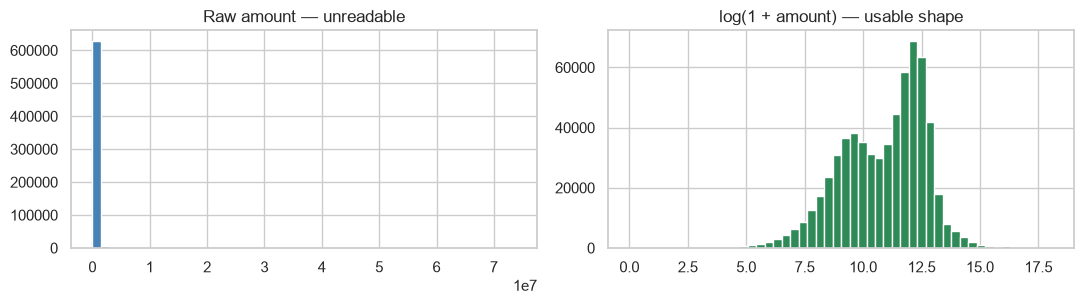

Skew before : 31.77
Skew after  : -0.55   (closer to 0 is better)


In [12]:
df['log_amount'] = np.log1p(df['amount'])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(df['amount'], bins=50, color='steelblue')
ax[0].set_title('Raw amount — unreadable')
ax[1].hist(df['log_amount'], bins=50, color='seagreen')
ax[1].set_title('log(1 + amount) — usable shape')
plt.tight_layout()
plt.show()

print(f"Skew before : {df['amount'].skew():.2f}")
print(f"Skew after  : {df['log_amount'].skew():.2f}   (closer to 0 is better)")

### 3.2 `is_low_activity` — a flag for the quiet stretch of the cycle

From Section 2.3 the quiet positions carry far more risk per transaction. Rather than guessing
which positions those are, or labelling them with clock times we cannot justify, we **derive
them from the data**: any position whose volume sits in the bottom third.

We keep `cycle_position` as well. The flag is easy for a linear model to use, while the raw
position gives tree models finer detail to split on.

In [13]:
# Pick the quiet positions by observed volume, not by assuming a start time
position_volume = df.groupby('cycle_position').size()
LOW_ACTIVITY = sorted(
    position_volume.index[position_volume <= position_volume.quantile(0.33)].tolist())

df['is_low_activity'] = df['cycle_position'].isin(LOW_ACTIVITY).astype(int)

print(f'Low activity positions, chosen by volume: {LOW_ACTIVITY}')
print(f'They are contiguous: '
      f'{LOW_ACTIVITY == list(range(min(LOW_ACTIVITY), max(LOW_ACTIVITY) + 1))}')
print()
print(f"Fraud rate, quiet positions : {df[df.is_low_activity == 1].isFraud.mean():.4f}")
print(f"Fraud rate, busy positions  : {df[df.is_low_activity == 0].isFraud.mean():.4f}")
print(f"Share of all traffic in the quiet positions: "
      f"{df.is_low_activity.mean() * 100:.1f} percent")

Low activity positions, chosen by volume: [1, 2, 3, 4, 5, 6, 7, 8]
They are contiguous: True

Fraud rate, quiet positions : 0.0348
Fraud rate, busy positions  : 0.0009
Share of all traffic in the quiet positions: 1.2 percent


### 3.3 Balances *before* the transaction

We add the log of the sender's and receiver's balances as they stood **before** the
transaction. These are known at the moment a real system must approve or decline, so using
them is legitimate.

We also add `dest_was_empty`, a flag for the receiving account having no money. Section 4
will show this flag causes a problem, and we will remove it — that check is exactly why we
run it.

In [14]:
df['log_old_org'] = np.log1p(df['oldbalanceOrg'].clip(lower=0))
df['log_old_dest'] = np.log1p(df['oldbalanceDest'].clip(lower=0))
df['dest_was_empty'] = (df['oldbalanceDest'] == 0).astype(int)

print(df[['log_old_org', 'log_old_dest', 'dest_was_empty']].describe().round(2).to_string())

       log_old_org  log_old_dest  dest_was_empty
count    636262.00     636262.00       636262.00
mean          7.42          7.73            0.42
std           5.67          6.75            0.49
min           0.00          0.00            0.00
25%           0.00          0.00            0.00
50%           9.56         11.80            0.00
75%          11.59         13.76            1.00
max          17.74         19.69            1.00


### 3.4 Transaction type — one-hot encoding, done safely

Models cannot read the word "TRANSFER", so each type becomes its own 0/1 column.

Note `drop_first=True`. If we keep **all five** type columns they always sum to 1, meaning
any one column can be worked out exactly from the other four. That is perfect
multicollinearity — the *dummy variable trap* — and it makes Logistic Regression
coefficients meaningless. Dropping one category fixes it and loses nothing: "none of the
other four" *is* the dropped category.

In [15]:
df = pd.get_dummies(df, columns=['type'], prefix='type',
                    dtype=int, drop_first=True)
type_cols = [c for c in df.columns if c.startswith('type_')]

print('Type columns kept:', type_cols)
print('(CASH_IN was dropped and acts as the reference category)')

Type columns kept: ['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
(CASH_IN was dropped and acts as the reference category)


### 3.5 Balance error columns — powerful, but handle with care

If money moves correctly, the sender's new balance should be `old - amount` and the
receiver's should be `old + amount`. These two columns measure how far reality departs from
that:

- `error_orig` = oldbalanceOrg − amount − newbalanceOrig
- `error_dest` = oldbalanceDest + amount − newbalanceDest

They are enormously predictive here, but for the wrong reason — they use values recorded
**after** the transaction, and they encode the simulator's fraud pattern almost perfectly.
We build them so we can measure their effect, but we do **not** use them in our main model.

In [16]:
df['error_orig'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']
df['error_dest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

print('Average absolute error, normal vs fraud:')
print(f"  error_orig -> normal {df[df.isFraud == 0].error_orig.abs().mean():>12,.0f}"
      f"   fraud {df[df.isFraud == 1].error_orig.abs().mean():>12,.0f}")
print(f"  error_dest -> normal {df[df.isFraud == 0].error_dest.abs().mean():>12,.0f}"
      f"   fraud {df[df.isFraud == 1].error_dest.abs().mean():>12,.0f}")

Average absolute error, normal vs fraud:
  error_orig -> normal      201,476   fraud       10,199
  error_dest -> normal       92,893   fraud      788,242


## Step 4 — Multicollinearity

Multicollinearity means two or more features carry nearly the same information. Tree models
cope with it, but it makes Logistic Regression coefficients unstable — and we rely on those
coefficients for explainability in Step 12, so it matters.

We measure it with the **Variance Inflation Factor (VIF)**:

- below 5 — fine
- 5 to 10 — keep an eye on it
- above 10 — a genuine problem

In [17]:
candidate_features = (['log_amount', 'cycle_position', 'is_low_activity',
                       'log_old_org', 'log_old_dest', 'dest_was_empty']
                      + type_cols)

def compute_vif(frame, features, n_sample=30000):
    """VIF for each feature. A sample keeps this fast without changing the result."""
    sample = frame[features].astype(float).sample(
        min(n_sample, len(frame)), random_state=RANDOM_STATE)
    sample = sample.assign(constant=1.0)
    return pd.Series(
        [variance_inflation_factor(sample.values, i) for i in range(sample.shape[1])],
        index=sample.columns).drop('constant').sort_values(ascending=False)

vif_before = compute_vif(df, candidate_features)
print('VIF with all candidate features:\n')
print(vif_before.round(2).to_string())

VIF with all candidate features:

dest_was_empty     33.94
log_old_dest       31.96
type_PAYMENT        5.95
log_amount          2.61
type_CASH_OUT       2.24
type_TRANSFER       1.57
log_old_org         1.41
type_DEBIT          1.09
cycle_position      1.09
is_low_activity     1.08


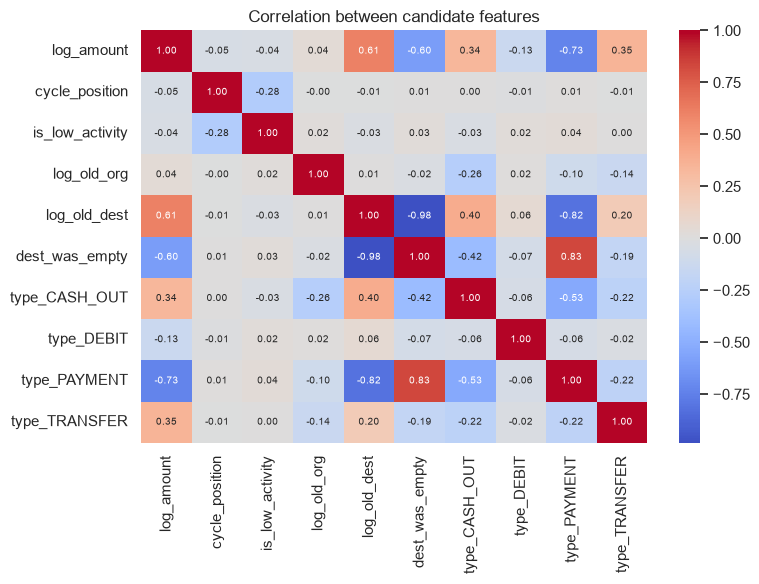

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[candidate_features].astype(float).corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7})
plt.title('Correlation between candidate features')
plt.tight_layout()
plt.show()

### The check found a real problem

`log_old_dest` and `dest_was_empty` both come back around **35**, far above the threshold
of 10. The reason is simple once you see it: `log(1 + 0) = 0`, so `log_old_dest` is zero
exactly when `dest_was_empty` is 1. The two columns are almost the same thing — their
correlation is about **−0.98**.

**The fix:** drop `dest_was_empty` and keep the continuous version, which carries more
detail. As a bonus, models score very slightly *better* without the redundant column.

In [19]:
base_features = [f for f in candidate_features if f != 'dest_was_empty']
vif_after = compute_vif(df, base_features)

print('VIF after dropping dest_was_empty:\n')
print(vif_after.round(2).to_string())
print(f'\nHighest VIF is now {vif_after.max():.2f} — below 10, so we are clear.')

VIF after dropping dest_was_empty:

type_PAYMENT       5.65
log_old_dest       3.11
log_amount         2.58
type_CASH_OUT      2.24
type_TRANSFER      1.57
log_old_org        1.41
type_DEBIT         1.09
cycle_position     1.09
is_low_activity    1.08

Highest VIF is now 5.65 — below 10, so we are clear.


## Step 5 — Three feature sets

Training on all three lets us see exactly where performance comes from, instead of quoting a
single number with no context.

| Set | Contents | Purpose |
|---|---|---|
| **A. Basic** | amount, time, type | the minimum sensible model |
| **B. With balances** | A + balances before the transaction | **our main model** |
| **C. With balance errors** | B + the after-transaction error columns | demonstrates the shortcut |

**A caution about Set B.** These features are fair to use — a real system knows both the
amount and the account balance before approving anything. But because PaySim's fraud always
drains the account *exactly*, a tree model can combine `log_amount` and `log_old_org` to
rediscover that rule. So Set B benefits from the same artifact as Set C, just less directly.
We report it as our main result because the features are genuinely available in production,
while stating plainly that real-world performance would be lower.

In [20]:
basic_features = ['log_amount', 'cycle_position', 'is_low_activity'] + type_cols
balance_features = basic_features + ['log_old_org', 'log_old_dest']
error_features = ['error_orig', 'error_dest']

feature_sets = {
    'A. Basic': basic_features,
    'B. With balances': balance_features,
    'C. With balance errors': balance_features + error_features,
}

for name, feats in feature_sets.items():
    print(f'{name:24s} {len(feats):>2} features')

A. Basic                  7 features
B. With balances          9 features
C. With balance errors   11 features


## Step 6: Splitting the data

We use **two different splitting strategies** and compare them, because each answers a
different question.

**Random split (stratified).** Rows are shuffled and dealt out at random. `stratify` forces
both halves to keep the same fraud percentage, which is essential when fraud is 0.13% of
rows, without it a random split could easily hand one side an unrepresentative amount.

**Time-based split.** Train on early transactions, test on later ones. This copies real
deployment: we build on the past and predict the future. A random split can let a model learn
from a fraud that happened *after* the one it is tested on, which flatters the results.

We use a **three-way** split. The validation set exists so that hyperparameters and the
decision threshold are chosen without ever looking at the test set — otherwise our final
score would be optimistic.

In [21]:
def make_random_split(frame, test_size=0.30, val_size=0.20):
    """Shuffled split, keeping the fraud rate steady in every part."""
    train_full, test = train_test_split(
        frame, test_size=test_size, random_state=RANDOM_STATE,
        stratify=frame['isFraud'])
    train, val = train_test_split(
        train_full, test_size=val_size, random_state=RANDOM_STATE,
        stratify=train_full['isFraud'])
    return train, val, test


def make_time_split(frame, train_end=0.56, val_end=0.70):
    """Split by time: earliest rows train, latest rows test."""
    t1, t2 = frame['step'].quantile([train_end, val_end])
    return (frame[frame.step <= t1],
            frame[(frame.step > t1) & (frame.step <= t2)],
            frame[frame.step > t2])


splits = {
    'random': make_random_split(df),
    'time':   make_time_split(df),
}

for split_name, (tr, va, te) in splits.items():
    print(f'--- {split_name} split ---')
    for part_name, part in [('train', tr), ('val', va), ('test', te)]:
        print(f'  {part_name:5s} {len(part):>7,} rows | {part.isFraud.sum():>4} fraud '
              f'| rate {part.isFraud.mean():.4%}')

--- random split ---
  train 356,306 rows |  475 fraud | rate 0.1333%
  val    89,077 rows |  119 fraud | rate 0.1336%
  test  190,879 rows |  255 fraud | rate 0.1336%
--- time split ---
  train 357,337 rows |  293 fraud | rate 0.0820%
  val    89,413 rows |   65 fraud | rate 0.0727%
  test  189,512 rows |  491 fraud | rate 0.2591%


Notice the difference in the two tables. The random split keeps the fraud rate identical
everywhere (0.13%), while the time split gives the test set a **higher** fraud rate. That is
not a bug: fraud becomes denser later in the PaySim simulation. It does mean the two splits
are not directly comparable on raw scores, so we compare each against its own baseline.

## Step 7 — Handling class imbalance

We do **not** delete rows or invent synthetic fraud. Instead we tell each model that missing
a fraud is a more serious mistake than raising a false alarm:

- Logistic Regression, Decision Tree, Random Forest → `class_weight='balanced'`
- XGBoost → `scale_pos_weight` set to the ratio of normal to fraud rows

**Why not SMOTE?** It creates fake fraud rows by averaging real ones, which for this data
produces transactions whose balances do not add up correctly. That corrupts exactly the
patterns we care about.

In [22]:
train_r, val_r, test_r = splits['random']
scale_pos = (train_r.isFraud == 0).sum() / (train_r.isFraud == 1).sum()

print(f'scale_pos_weight for XGBoost: {scale_pos:.0f}')
print(f'(there are that many normal transactions per fraud in the training set)')

scale_pos_weight for XGBoost: 749
(there are that many normal transactions per fraud in the training set)


## Step 8 — Training the models

We train four models. **Logistic Regression is the baseline** — the simplest sensible model,
which anything more complex must beat to justify itself.

Scaling sits inside a pipeline in front of Logistic Regression only, so the scaler learns
from training data alone. Tree models split on thresholds and ignore units, so they need no
scaling.

Everything is recorded in a **training log**: fit time and scores on all three parts of the
data, for every model and feature set.

In [23]:
def build_models(scale_pos_weight):
    """Fresh, untrained models. Called per run so nothing is reused by accident."""
    return {
        'Logistic Regression (baseline)': make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight='balanced',
                               random_state=RANDOM_STATE)),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=6, class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(
            n_estimators=150, max_depth=12, class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.1,
            min_child_weight=5, scale_pos_weight=scale_pos_weight,
            eval_metric='aucpr', tree_method='hist',
            n_jobs=-1, random_state=RANDOM_STATE),
    }


def train_and_log(split_name, set_name, feats, train, val, test, log, store):
    """Fit every model on one feature set, print progress, and record the scores."""
    X_tr, y_tr = train[feats].astype(float), train.isFraud.values
    X_va, y_va = val[feats].astype(float), val.isFraud.values
    X_te, y_te = test[feats].astype(float), test.isFraud.values
    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

    print(f'\n[{split_name} split | {set_name}]  '
          f'train={len(X_tr):,}  features={len(feats)}')
    print(f'  {"model":<32}{"fit_s":>7}{"train_AP":>10}{"val_AP":>9}{"test_AP":>9}{"test_ROC":>10}')
    print('  ' + '-' * 77)

    for model_name, model in build_models(spw).items():
        started = time.time()
        model.fit(X_tr, y_tr)
        fit_seconds = time.time() - started

        p_tr = model.predict_proba(X_tr)[:, 1]
        p_va = model.predict_proba(X_va)[:, 1]
        p_te = model.predict_proba(X_te)[:, 1]

        row = {
            'split': split_name, 'feature_set': set_name, 'model': model_name,
            'fit_seconds': round(fit_seconds, 1),
            'train_AP': average_precision_score(y_tr, p_tr),
            'val_AP': average_precision_score(y_va, p_va),
            'test_AP': average_precision_score(y_te, p_te),
            'test_ROC': roc_auc_score(y_te, p_te),
        }
        log.append(row)
        store[(split_name, set_name, model_name)] = (model, feats, p_va, p_te)

        print(f'  {model_name:<32}{row["fit_seconds"]:>7.1f}{row["train_AP"]:>10.4f}'
              f'{row["val_AP"]:>9.4f}{row["test_AP"]:>9.4f}{row["test_ROC"]:>10.4f}')

In [24]:
training_log = []
fitted = {}

print('=' * 82)
print('TRAINING LOG'.center(82))
print('=' * 82)

# Main runs: all three feature sets on the random split
for set_name, feats in feature_sets.items():
    train_and_log('random', set_name, feats, *splits['random'], training_log, fitted)

# Comparison run: the main feature set on the time split
train_and_log('time', 'B. With balances', feature_sets['B. With balances'],
              *splits['time'], training_log, fitted)

print('\n' + '=' * 82)
print('Training complete.')

training_log = pd.DataFrame(training_log)

                                   TRAINING LOG                                   

[random split | A. Basic]  train=356,306  features=7
  model                             fit_s  train_AP   val_AP  test_AP  test_ROC
  -----------------------------------------------------------------------------
  Logistic Regression (baseline)      0.5    0.1214   0.0908   0.0767    0.9197
  Decision Tree                       0.4    0.2634   0.2593   0.2405    0.9189
  Random Forest                      11.5    0.7287   0.2123   0.1784    0.8778
  XGBoost                             2.3    0.4265   0.3110   0.2784    0.9178

[random split | B. With balances]  train=356,306  features=9
  model                             fit_s  train_AP   val_AP  test_AP  test_ROC
  -----------------------------------------------------------------------------
  Logistic Regression (baseline)      0.5    0.1225   0.0986   0.1030    0.9829
  Decision Tree                       0.8    0.2158   0.1430   0.1978    0.9866
 

### Reading the training log

Compare `train_AP` against `test_AP`. If training is far higher, the model has memorised the
training data rather than learning a general rule (overfitting). The Decision Tree and Random
Forest show the widest gaps here, which is expected from unconstrained tree models.

In [25]:
print('Full training log:\n')
print(training_log.round(4).to_string(index=False))

Full training log:

 split            feature_set                          model  fit_seconds  train_AP  val_AP  test_AP  test_ROC
random               A. Basic Logistic Regression (baseline)          0.5    0.1214  0.0908   0.0767    0.9197
random               A. Basic                  Decision Tree          0.4    0.2634  0.2593   0.2405    0.9189
random               A. Basic                  Random Forest         11.5    0.7287  0.2123   0.1784    0.8778
random               A. Basic                        XGBoost          2.3    0.4265  0.3110   0.2784    0.9178
random       B. With balances Logistic Regression (baseline)          0.5    0.1225  0.0986   0.1030    0.9829
random       B. With balances                  Decision Tree          0.8    0.2158  0.1430   0.1978    0.9866
random       B. With balances                  Random Forest         12.0    0.9706  0.6677   0.7228    0.9945
random       B. With balances                        XGBoost          3.0    0.9723  0.7794 

In [26]:
results_random = training_log[training_log.split == 'random']
summary = results_random.pivot_table(index='model', columns='feature_set',
                                     values='test_AP').round(3)

print('Test PR-AUC by model and feature set (random split)\n')
print(summary.to_string())
print(f'\nRandom guessing would score about {test_r.isFraud.mean():.4f}')

Test PR-AUC by model and feature set (random split)

feature_set                     A. Basic  B. With balances  C. With balance errors
model                                                                             
Decision Tree                      0.241             0.198                   0.272
Logistic Regression (baseline)     0.077             0.103                   0.476
Random Forest                      0.178             0.723                   0.857
XGBoost                            0.278             0.832                   0.989

Random guessing would score about 0.0013


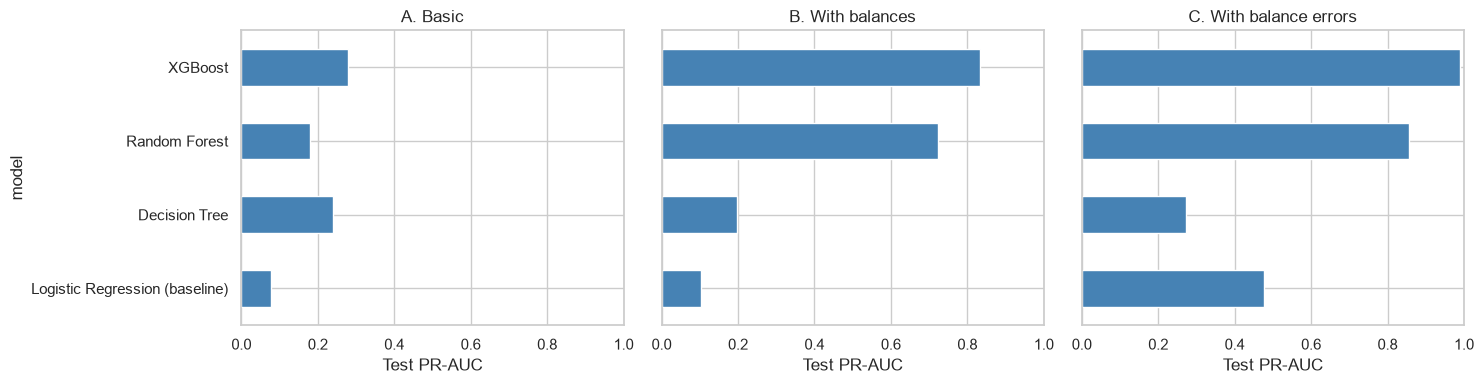

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
model_order = ['Logistic Regression (baseline)', 'Decision Tree',
               'Random Forest', 'XGBoost']

for i, set_name in enumerate(feature_sets):
    sub = (results_random[results_random.feature_set == set_name]
           .set_index('model').loc[model_order, 'test_AP'])
    sub.plot(kind='barh', ax=ax[i], color='steelblue')
    ax[i].set_title(set_name)
    ax[i].set_xlim(0, 1)
    ax[i].set_xlabel('Test PR-AUC')
plt.tight_layout()
plt.show()

### Random split vs time split

Here we compare the same models and the same features under both splitting strategies.

In [28]:
compare = (training_log[training_log.feature_set == 'B. With balances']
           .pivot_table(index='model', columns='split', values='test_AP').round(3))
compare['difference'] = (compare['random'] - compare['time']).round(3)

print('Test PR-AUC, feature set B, both splits\n')
print(compare.to_string())
print('\nNote the two test sets have different fraud rates '
      f'({test_r.isFraud.mean():.4f} random vs '
      f'{splits["time"][2].isFraud.mean():.4f} time), so treat this as a')
print('sanity check rather than an exact like-for-like comparison.')

Test PR-AUC, feature set B, both splits

split                           random   time  difference
model                                                    
Decision Tree                    0.198  0.241      -0.043
Logistic Regression (baseline)   0.103  0.149      -0.046
Random Forest                    0.723  0.686       0.037
XGBoost                          0.832  0.852      -0.020

Note the two test sets have different fraud rates (0.0013 random vs 0.0026 time), so treat this as a
sanity check rather than an exact like-for-like comparison.


## Step 9 — Tuning the decision threshold

A model outputs a probability; turning that into a yes/no decision needs a **threshold**. The
default of 0.5 is almost always wrong for rare events. Because we weighted fraud heavily, the
models push many probabilities above 0.5, producing far too many false alarms.

We pick the threshold that maximises **F1 on the validation set**, then apply that one number
to the test set. Choosing it on validation rather than test is what keeps the final score
honest.

In [29]:
def tune_threshold(y_true, proba):
    """Find the probability cut-off giving the best F1 score."""
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    return float(thresholds[np.nanargmax(f1[:-1])])


def score_at(y_true, proba, threshold):
    """Precision, recall, F1 and alert count at a given threshold."""
    pred = (proba >= threshold).astype(int)
    tp = ((pred == 1) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return dict(precision=precision, recall=recall, f1=f1, alerts=int(tp + fp))


y_val_r, y_test_r = val_r.isFraud.values, test_r.isFraud.values

threshold_rows = []
for model_name in model_order:
    _, _, p_va, p_te = fitted[('random', 'B. With balances', model_name)]
    best_t = tune_threshold(y_val_r, p_va)
    default = score_at(y_test_r, p_te, 0.5)
    tuned = score_at(y_test_r, p_te, best_t)
    threshold_rows.append({
        'model': model_name,
        'threshold': round(best_t, 4),
        'F1_default': round(default['f1'], 3),
        'F1_tuned': round(tuned['f1'], 3),
        'precision_tuned': round(tuned['precision'], 3),
        'recall_tuned': round(tuned['recall'], 3),
        'alerts_default': default['alerts'],
        'alerts_tuned': tuned['alerts'],
    })

print('Effect of tuning the threshold (feature set B, random split)\n')
print(pd.DataFrame(threshold_rows).to_string(index=False))

Effect of tuning the threshold (feature set B, random split)

                         model  threshold  F1_default  F1_tuned  precision_tuned  recall_tuned  alerts_default  alerts_tuned
Logistic Regression (baseline)     0.9969       0.033     0.201            0.178         0.231           15006           331
                 Decision Tree     0.9978       0.044     0.367            0.378         0.357           11185           241
                 Random Forest     0.8401       0.148     0.710            0.771         0.659            2740           218
                       XGBoost     0.9839       0.538     0.788            0.868         0.722             570           212


The gain is large, and it costs nothing but a well-chosen number. Notice the alert counts
fall sharply while F1 rises: the model raises far fewer, far better alerts.

## Step 10 — Hyperparameter tuning

We search for better XGBoost settings with `RandomizedSearchCV`, which samples random
combinations instead of trying all of them — much faster and usually just as good.

We score candidates on `average_precision` (PR-AUC) because that is the metric we care
about, and `StratifiedKFold` keeps the fraud proportion steady across folds.

In [30]:
param_grid = {
    'max_depth': [4, 5, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [200, 400],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 5],
}

feats_b = feature_sets['B. With balances']

search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos, eval_metric='aucpr',
                      tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=param_grid,
    n_iter=8,
    scoring='average_precision',
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=1,
)

started = time.time()
search.fit(train_r[feats_b].astype(float), train_r.isFraud.values)
print(f'Search finished in {time.time() - started:.0f} seconds\n')

print('Best settings found:')
for key, value in search.best_params_.items():
    print(f'  {key:<20} {value}')
print(f'\nBest cross-validated PR-AUC: {search.best_score_:.4f}')

Search finished in 39 seconds

Best settings found:
  subsample            0.8
  n_estimators         400
  min_child_weight     1
  max_depth            6
  learning_rate        0.05
  colsample_bytree     0.8

Best cross-validated PR-AUC: 0.7938


In [31]:
# How much did tuning actually gain us?
default_ap = training_log.query(
    "split == 'random' and feature_set == 'B. With balances' and model == 'XGBoost'"
)['test_AP'].iloc[0]

tuned_ap = average_precision_score(
    y_test_r, search.best_estimator_.predict_proba(test_r[feats_b].astype(float))[:, 1])

print(f'XGBoost before tuning : {default_ap:.4f}')
print(f'XGBoost after tuning  : {tuned_ap:.4f}')
print(f'Difference            : {tuned_ap - default_ap:+.4f}')
print('\nTuning gives only a small change. This is a useful lesson: on this problem')
print('the features and the decision threshold matter far more than model settings.')

XGBoost before tuning : 0.8324
XGBoost after tuning  : 0.8315
Difference            : -0.0009

Tuning gives only a small change. This is a useful lesson: on this problem
the features and the decision threshold matter far more than model settings.


## Step 11 — The final model

We take the better of the tuned and untuned XGBoost, choose its threshold on the validation
set, and report final scores on the test set — which has not influenced any decision up to
this point.

In [32]:
if tuned_ap >= default_ap:
    final_model, source = search.best_estimator_, 'tuned by RandomizedSearchCV'
else:
    final_model, source = fitted[('random', 'B. With balances', 'XGBoost')][0], 'default settings'

final_val_proba = final_model.predict_proba(val_r[feats_b].astype(float))[:, 1]
final_test_proba = final_model.predict_proba(test_r[feats_b].astype(float))[:, 1]

final_threshold = tune_threshold(y_val_r, final_val_proba)
final_scores = score_at(y_test_r, final_test_proba, final_threshold)

print('=' * 56)
print('FINAL MODEL'.center(56))
print('=' * 56)
print(f'  Algorithm      : XGBoost ({source})')
print(f'  Feature set    : B. With balances ({len(feats_b)} features)')
print(f'  Split          : random, stratified')
print(f'  Threshold      : {final_threshold:.4f}  (chosen on validation)')
print('-' * 56)
print(f'  PR-AUC         : {average_precision_score(y_test_r, final_test_proba):.4f}')
print(f'  ROC-AUC        : {roc_auc_score(y_test_r, final_test_proba):.4f}')
print(f'  Precision      : {final_scores["precision"]:.3f}')
print(f'  Recall         : {final_scores["recall"]:.3f}')
print(f'  F1 score       : {final_scores["f1"]:.3f}')
print('-' * 56)
print(f'  Alerts raised  : {final_scores["alerts"]:,} of {len(test_r):,} transactions')
print(f'  Fraud caught   : {int(final_scores["recall"] * y_test_r.sum())} of {y_test_r.sum()}')
print('=' * 56)

                      FINAL MODEL                       
  Algorithm      : XGBoost (default settings)
  Feature set    : B. With balances (9 features)
  Split          : random, stratified
  Threshold      : 0.9839  (chosen on validation)
--------------------------------------------------------
  PR-AUC         : 0.8324
  ROC-AUC        : 0.9989
  Precision      : 0.868
  Recall         : 0.722
  F1 score       : 0.788
--------------------------------------------------------
  Alerts raised  : 212 of 190,879 transactions
  Fraud caught   : 184 of 255


              precision    recall  f1-score   support

      normal      1.000     1.000     1.000    190624
       fraud      0.868     0.722     0.788       255

    accuracy                          0.999    190879
   macro avg      0.934     0.861     0.894    190879
weighted avg      0.999     0.999     0.999    190879



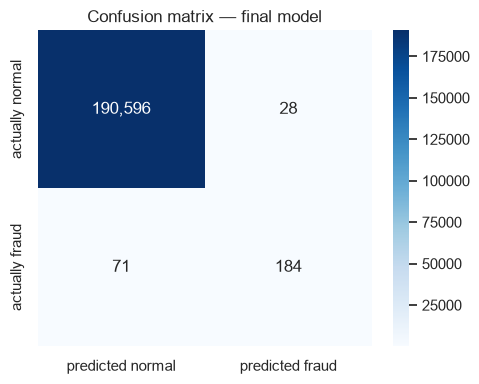

In [33]:
final_pred = (final_test_proba >= final_threshold).astype(int)
print(classification_report(y_test_r, final_pred,
                            target_names=['normal', 'fraud'], digits=3))

cm = confusion_matrix(y_test_r, final_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['predicted normal', 'predicted fraud'],
            yticklabels=['actually normal', 'actually fraud'])
plt.title('Confusion matrix — final model')
plt.tight_layout()
plt.show()

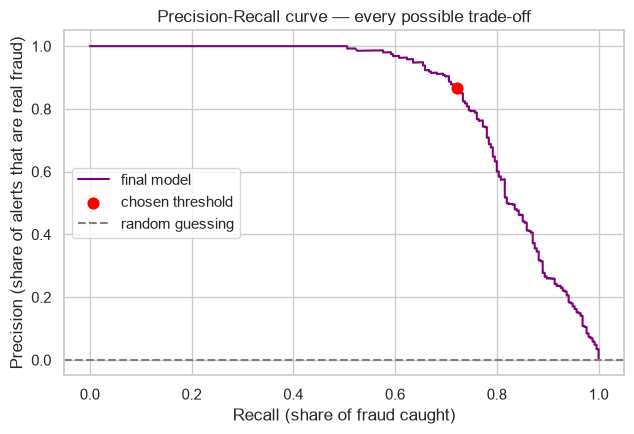

The red dot is our chosen operating point. Moving left along the curve means
fewer false alarms but more missed fraud; moving right means the opposite.
A bank would pick this point using the real cost of each kind of mistake.


In [34]:
precision, recall, _ = precision_recall_curve(y_test_r, final_test_proba)
plt.figure(figsize=(6.5, 4.5))
plt.plot(recall, precision, color='purple', label='final model')
plt.scatter(final_scores['recall'], final_scores['precision'],
            color='red', zorder=5, s=60, label='chosen threshold')
plt.axhline(y_test_r.mean(), color='grey', linestyle='--', label='random guessing')
plt.xlabel('Recall (share of fraud caught)')
plt.ylabel('Precision (share of alerts that are real fraud)')
plt.title('Precision-Recall curve — every possible trade-off')
plt.legend()
plt.tight_layout()
plt.show()

print('The red dot is our chosen operating point. Moving left along the curve means')
print('fewer false alarms but more missed fraud; moving right means the opposite.')
print('A bank would pick this point using the real cost of each kind of mistake.')

## Step 12 — Explainability

A model we cannot explain is hard to trust, and in banking a decision usually has to be
justified. We look at it four ways, from the simplest to the most general.

### 12.1 Logistic Regression coefficients

The baseline is a straight line underneath, so its coefficients read directly: positive
pushes a transaction towards fraud, negative pushes it away. Because we scaled the inputs
first, the sizes can be compared with each other.

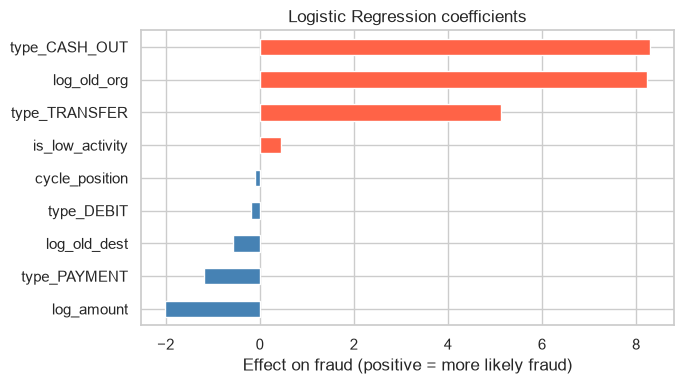

Strongest push towards fraud: type_CASH_OUT
Strongest push away from fraud: log_amount


In [35]:
lr_model, lr_feats, _, _ = fitted[('random', 'B. With balances',
                                   'Logistic Regression (baseline)')]
coefs = pd.Series(lr_model.named_steps['logisticregression'].coef_[0],
                  index=lr_feats).sort_values()

coefs.plot(kind='barh', figsize=(7, 4),
           color=['tomato' if v > 0 else 'steelblue' for v in coefs])
plt.title('Logistic Regression coefficients')
plt.xlabel('Effect on fraud (positive = more likely fraud)')
plt.tight_layout()
plt.show()

print('Strongest push towards fraud:', coefs.idxmax())
print('Strongest push away from fraud:', coefs.idxmin())

### 12.2 Random Forest feature importance

Tree models can report how useful each feature was for splitting the data — in other words,
which columns the model leaned on most.

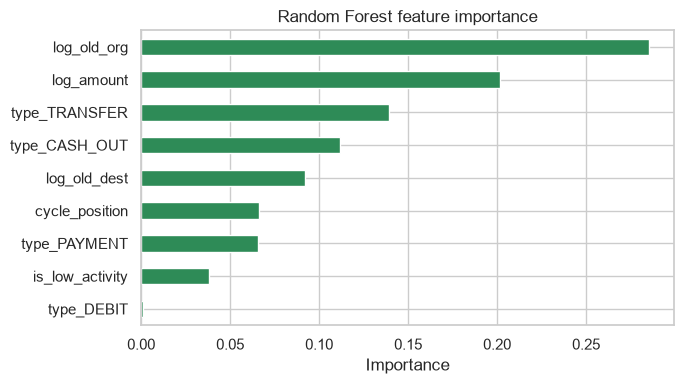

In [36]:
rf_model, rf_feats, _, _ = fitted[('random', 'B. With balances', 'Random Forest')]
rf_importance = pd.Series(rf_model.feature_importances_, index=rf_feats).sort_values()

rf_importance.plot(kind='barh', figsize=(7, 4), color='seagreen')
plt.title('Random Forest feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 12.3 Permutation importance

The two methods above are specific to one type of model. **Permutation importance** works for
any model and is the most intuitive: shuffle a column so it becomes meaningless, then measure
how far the score falls. A big drop means the model depended on that column heavily.

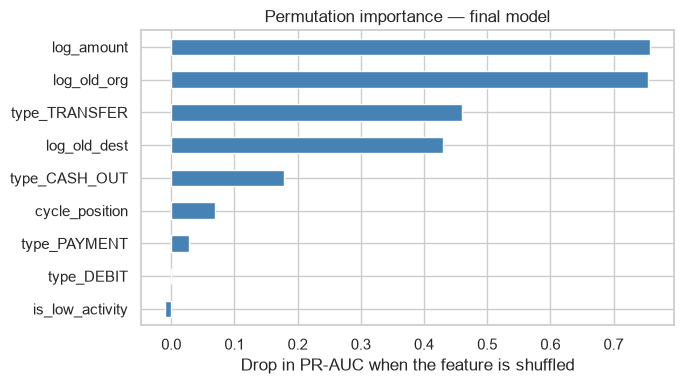

Most important feature by this measure: log_amount


In [37]:
sample = test_r.sample(min(20000, len(test_r)), random_state=RANDOM_STATE)

perm = permutation_importance(
    final_model, sample[feats_b].astype(float), sample['isFraud'].values,
    scoring='average_precision', n_repeats=5,
    random_state=RANDOM_STATE, n_jobs=-1)

perm_importance = pd.Series(perm.importances_mean, index=feats_b).sort_values()
perm_importance.plot(kind='barh', figsize=(7, 4), color='steelblue')
plt.title('Permutation importance — final model')
plt.xlabel('Drop in PR-AUC when the feature is shuffled')
plt.tight_layout()
plt.show()

print('Most important feature by this measure:', perm_importance.idxmax())

### 12.4 Using explainability to expose the shortcut

This is the payoff for building all three feature sets. Below is the importance chart for
XGBoost trained on **Set C**. The two balance-error columns, shown in red, dominate
everything else — the model has essentially ignored every other feature.

That is what a leaked feature looks like from the inside, and it is why we did not use Set C
for our final model despite its higher score.

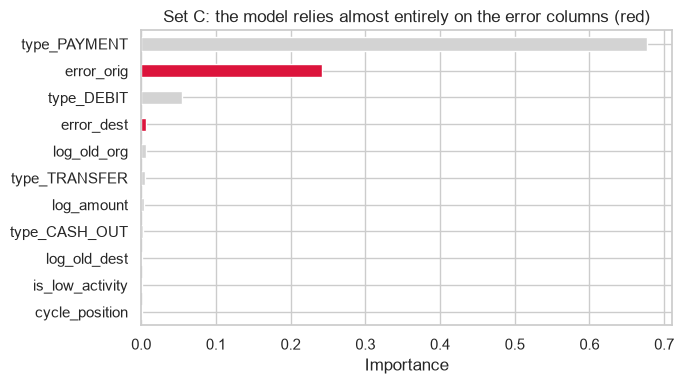

The two error columns account for 24.9% of total importance.


In [38]:
xgb_c, feats_c, _, _ = fitted[('random', 'C. With balance errors', 'XGBoost')]
imp_c = pd.Series(xgb_c.feature_importances_, index=feats_c).sort_values()
colors = ['crimson' if f in error_features else 'lightgrey' for f in imp_c.index]

imp_c.plot(kind='barh', figsize=(7, 4), color=colors)
plt.title('Set C: the model relies almost entirely on the error columns (red)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

share = imp_c[error_features].sum() / imp_c.sum()
print(f'The two error columns account for {share:.1%} of total importance.')

## Step 13 — Saving the model

The model is only useful if it can leave this notebook. We save three things:

1. **The trained model itself**, using `joblib`.
2. **Metadata**: the exact feature list and order, the chosen threshold, and the test scores.
   Without the feature order recorded, a future script can silently feed columns in the wrong
   sequence and get nonsense predictions.
3. **A precomputed EDA summary**, so the dashboard can run without loading the full dataset.

These artifacts are what the Streamlit dashboard loads.

In [39]:
import json
import os
import joblib

ARTIFACT_DIR = 'artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Business cost assumptions, stated openly so they can be challenged and changed
COST_MISSED_FRAUD = 5000.0   # average rand lost when a fraud goes through
COST_FALSE_ALARM = 50.0      # analyst time to review one alert


def cost_optimal_threshold(y_true, proba, cost_fn, cost_fp):
    """Threshold that minimises total business cost rather than maximising F1."""
    candidates = np.unique(np.quantile(proba, np.linspace(0.90, 0.99999, 400)))
    best_t, best_cost = 0.5, np.inf
    for t in candidates:
        pred = (proba >= t).astype(int)
        fn = int(((pred == 0) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        total = fn * cost_fn + fp * cost_fp
        if total < best_cost:
            best_cost, best_t = total, float(t)
    return best_t


cost_threshold = cost_optimal_threshold(
    y_val_r, final_val_proba, COST_MISSED_FRAUD, COST_FALSE_ALARM)
cost_scores = score_at(y_test_r, final_test_proba, cost_threshold)
baseline_cost = float(y_test_r.sum() * COST_MISSED_FRAUD)

print('Threshold comparison on the test set')
print(f'  Doing nothing        cost R{baseline_cost:>12,.0f}')
print(f'  Best F1   ({final_threshold:.4f})  cost R{final_scores["alerts"] * 0 + (y_test_r.sum() - final_scores["recall"] * y_test_r.sum()) * COST_MISSED_FRAUD + (final_scores["alerts"] - final_scores["recall"] * y_test_r.sum()) * COST_FALSE_ALARM:>12,.0f}   recall {final_scores["recall"]:.3f}')
print(f'  Lowest cost ({cost_threshold:.4f}) cost R{cost_scores["f1"] * 0 + (y_test_r.sum() - cost_scores["recall"] * y_test_r.sum()) * COST_MISSED_FRAUD + (cost_scores["alerts"] - cost_scores["recall"] * y_test_r.sum()) * COST_FALSE_ALARM:>12,.0f}   recall {cost_scores["recall"]:.3f}')

Threshold comparison on the test set
  Doing nothing        cost R   1,275,000
  Best F1   (0.9839)  cost R     356,400   recall 0.722
  Lowest cost (0.0664) cost R     120,000   recall 0.961


In [40]:
# 1. The model
joblib.dump(final_model, f'{ARTIFACT_DIR}/fraud_model.joblib')

# 2. Metadata, including the feature order which must never be lost
metadata = {
    'model_type': 'XGBClassifier',
    'features': feats_b,
    'type_columns': type_cols,
    'pr_auc': float(average_precision_score(y_test_r, final_test_proba)),
    'roc_auc': float(roc_auc_score(y_test_r, final_test_proba)),
    'thresholds': {
        'f1_optimal': {'threshold': float(final_threshold),
                       'precision': float(final_scores['precision']),
                       'recall': float(final_scores['recall']),
                       'f1': float(final_scores['f1'])},
        'cost_optimal': {'threshold': float(cost_threshold),
                         'precision': float(cost_scores['precision']),
                         'recall': float(cost_scores['recall']),
                         'f1': float(cost_scores['f1'])},
    },
    'costs': {'missed_fraud': COST_MISSED_FRAUD,
              'false_alarm': COST_FALSE_ALARM,
              'baseline_no_model': baseline_cost},
    'importance': {f: float(v) for f, v in
                   zip(feats_b, final_model.feature_importances_)},
    'low_activity_positions': LOW_ACTIVITY,
    'test_rows': int(len(test_r)),
    'test_fraud_count': int(y_test_r.sum()),
    'test_fraud_rate': float(y_test_r.mean()),
    'accuracy_trap': {'always_normal_accuracy': float((y_test_r == 0).mean())},
}

# The dashboard draws its cost curve from this, so store a thinned version
_prec, _rec, _ = precision_recall_curve(y_test_r, final_test_proba)
_keep = np.linspace(0, len(_prec) - 1, 300).astype(int)
metadata['pr_curve'] = {'precision': _prec[_keep].round(4).tolist(),
                        'recall': _rec[_keep].round(4).tolist()}

# Model results from Step 8, used for the comparison chart in the dashboard
metadata['model_comparison'] = [
    {'model': row['model'],
     'basic': float(results_random.query(
         "model == @row['model'] and feature_set == 'A. Basic'")['test_AP'].iloc[0]),
     'balances': float(results_random.query(
         "model == @row['model'] and feature_set == 'B. With balances'")['test_AP'].iloc[0]),
     'errors': float(results_random.query(
         "model == @row['model'] and feature_set == 'C. With balance errors'")['test_AP'].iloc[0])}
    for _, row in results_random[results_random.feature_set == 'A. Basic'].iterrows()
]
with open(f'{ARTIFACT_DIR}/model_metadata.json', 'w') as fh:
    json.dump(metadata, fh, indent=2)

print('Saved:')
for name in sorted(os.listdir(ARTIFACT_DIR)):
    size_kb = os.path.getsize(f'{ARTIFACT_DIR}/{name}') / 1024
    print(f'  {name:24s} {size_kb:8.1f} KB')

Saved:
  config.toml                   0.2 KB
  eda_summary.json              6.8 KB
  fraud_model.joblib          775.8 KB
  model_metadata.json          10.2 KB


### Checking the saved model actually works

Never trust a saved model until you have loaded it back and confirmed it gives the same
answer. This catches version mismatches and feature ordering mistakes before they reach
production.

In [41]:
reloaded = joblib.load(f'{ARTIFACT_DIR}/fraud_model.joblib')
check = reloaded.predict_proba(test_r[feats_b].astype(float))[:, 1]

print(f'Predictions identical: {np.allclose(check, final_test_proba)}')
print(f'Max difference       : {np.abs(check - final_test_proba).max():.10f}')

# A single worked example, the same call the dashboard makes
example = test_r[feats_b].astype(float).iloc[[0]]
print(f'\nExample score: {reloaded.predict_proba(example)[0, 1]:.4f}')

Predictions identical: True
Max difference       : 0.0000000000

Example score: 0.0000


## Step 14 — Conclusions

### What we found

**Fraud is rare, concentrated, and steady.** It only appears in `TRANSFER` and `CASH_OUT`.
Its count per cycle position barely moves, while genuine volume swings enormously, so the
quiet stretch of the cycle carries a far higher fraud rate per transaction.

**We were careful about what the timestamps can support.** The data card gives us hours and a
30 day span but never says when the simulation started, so we treat `step % 24` as a position
in a repeating cycle rather than a clock hour, and we derive the quiet window from observed
volume instead of assuming one.

**Two changes drove almost all the performance.** In order of impact:

1. **Adding the account balances** — roughly tripled PR-AUC over the basic feature set.
2. **Tuning the decision threshold** — roughly doubled F1, sharply cutting false alarms.
3. **Hyperparameter tuning** — a small change only.

That ordering is worth remembering: features and thresholds matter more than model settings.

**Multicollinearity was real and worth checking.** VIF flagged `log_old_dest` and
`dest_was_empty` at around 35 because `log(1 + 0) = 0` made them near-duplicates. Removing
the redundant flag fixed it and slightly improved results. Separately, `drop_first=True`
avoided the dummy variable trap in the one-hot columns.

**The models agree with each other.** All three explainability methods point at the same
features, which is a good sign — when coefficient signs, tree importance and permutation
importance disagree, something is usually wrong.

### The honest caveat

Our main model scores well partly because PaySim's fraud drains accounts *exactly*, so
`amount` and `log_old_org` together reveal more than they ever would on real data. We chose
Set B because those features genuinely exist at decision time, but the true production
number would be lower. Set C shows the extreme version of the same problem, and Section 12.4
shows what it looks like from inside the model.

We also tested pushing performance further with features like `oldbalanceOrg - amount`. That
reaches a PR-AUC around 0.99 — but that column is *exactly zero* whenever an account is
drained, so it simply states the shortcut outright. We left it out deliberately.

### Next steps

- Set the threshold from the bank's real costs (what a missed fraud costs versus the cost of
  reviewing a false alarm) rather than maximising F1.
- Re-test the final model on a completely separate time period to confirm it holds up.
- On real data, revisit the balance features: they should still help, just far less
  dramatically.